In [2]:
import kagglehub

kagglehub.login()

# Download latest version
path = kagglehub.dataset_download("youssefaboelwafa/clustering-penguins-species")

print("Path to dataset files:", path)

Path to dataset files: /Users/raymundomc/.cache/kagglehub/datasets/youssefaboelwafa/clustering-penguins-species/versions/1


In [ ]:
import os

print("Dataset path:", path)
print("Files inside:", os.listdir(path))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats



csv_path = os.path.join(path,"penguins.csv")
df = pd.read_csv(csv_path)

print(df.head())

Dataset path: /Users/raymundomc/.cache/kagglehub/datasets/youssefaboelwafa/clustering-penguins-species/versions/1
Files inside: ['penguins.csv']
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g     sex
0              39.1             18.7              181.0       3750.0    MALE
1              39.5             17.4              186.0       3800.0  FEMALE
2              40.3             18.0              195.0       3250.0  FEMALE
3               NaN              NaN                NaN          NaN     NaN
4              36.7             19.3              193.0       3450.0  FEMALE


In [4]:
df.head(5)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
df.shape

(344, 5)

In [6]:
df.columns

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [8]:
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [11]:
df["sex"].unique()




array(['MALE', 'FEMALE', '.'], dtype=object)

In [12]:
mask = df['sex'] == '.'

df = df[~mask]

print(df["sex"].unique())

['MALE' 'FEMALE']


In [13]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex'],
    drop_first=True,
    dtype=int
)

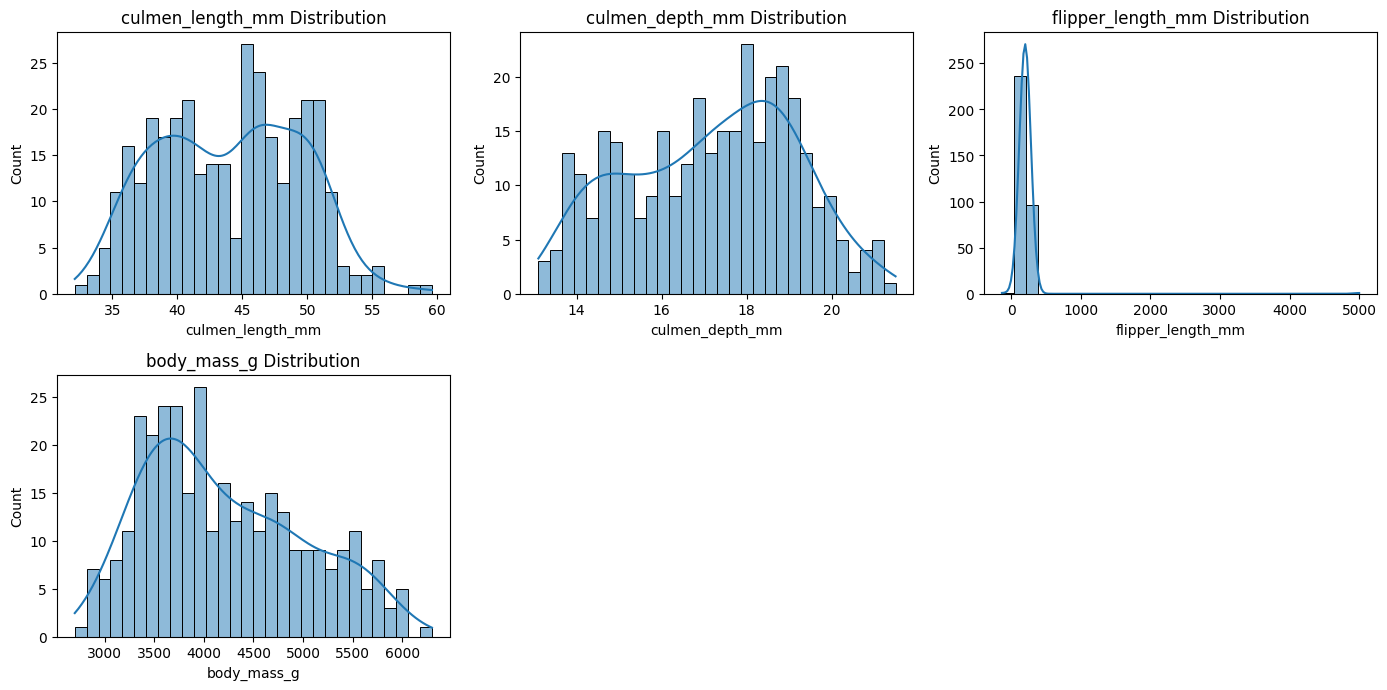

In [14]:
numeric_cols = ['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']
    
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


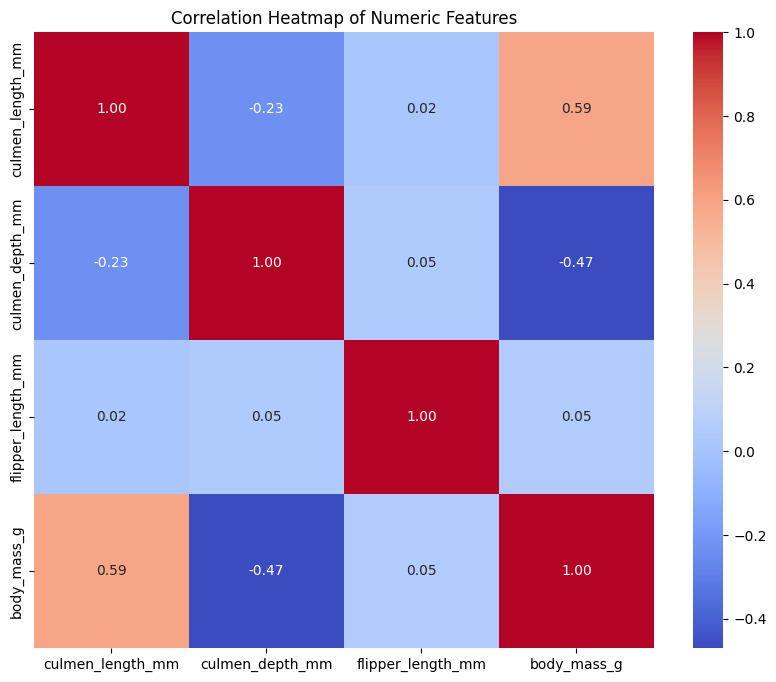

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

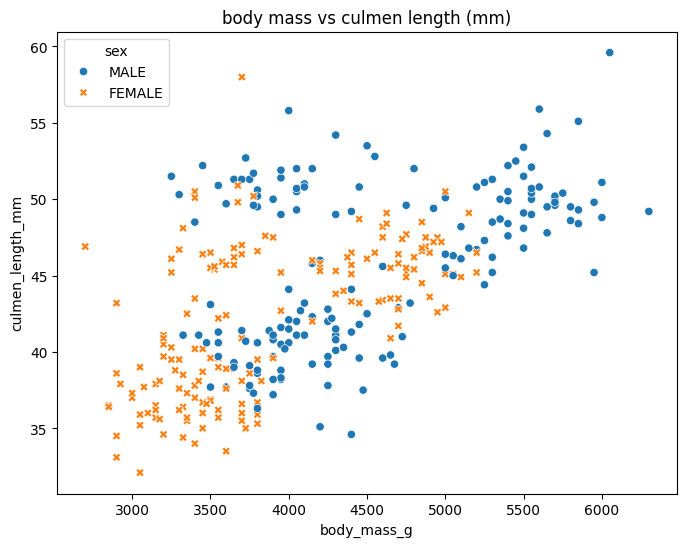

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='body_mass_g', y='culmen_length_mm', hue='sex',style='sex', data=df)
plt.title('body mass vs culmen length (mm)')
plt.show()

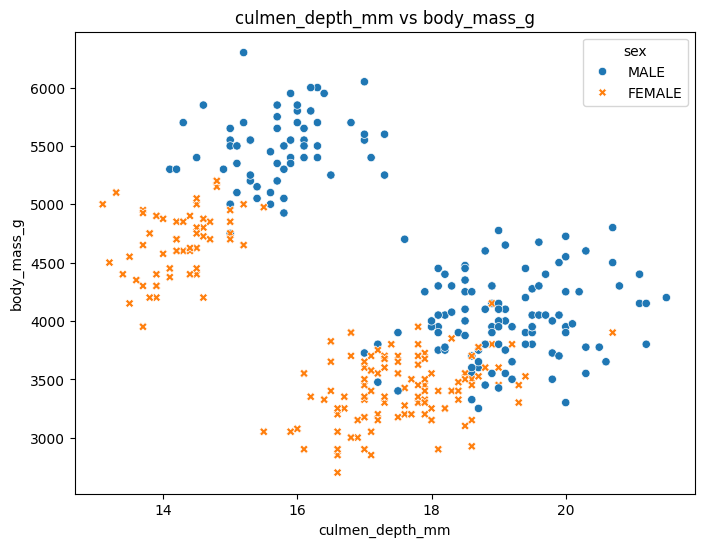

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='culmen_depth_mm',y='body_mass_g', hue='sex',style='sex',data=df)
plt.title('culmen_depth_mm vs body_mass_g')
plt.show()

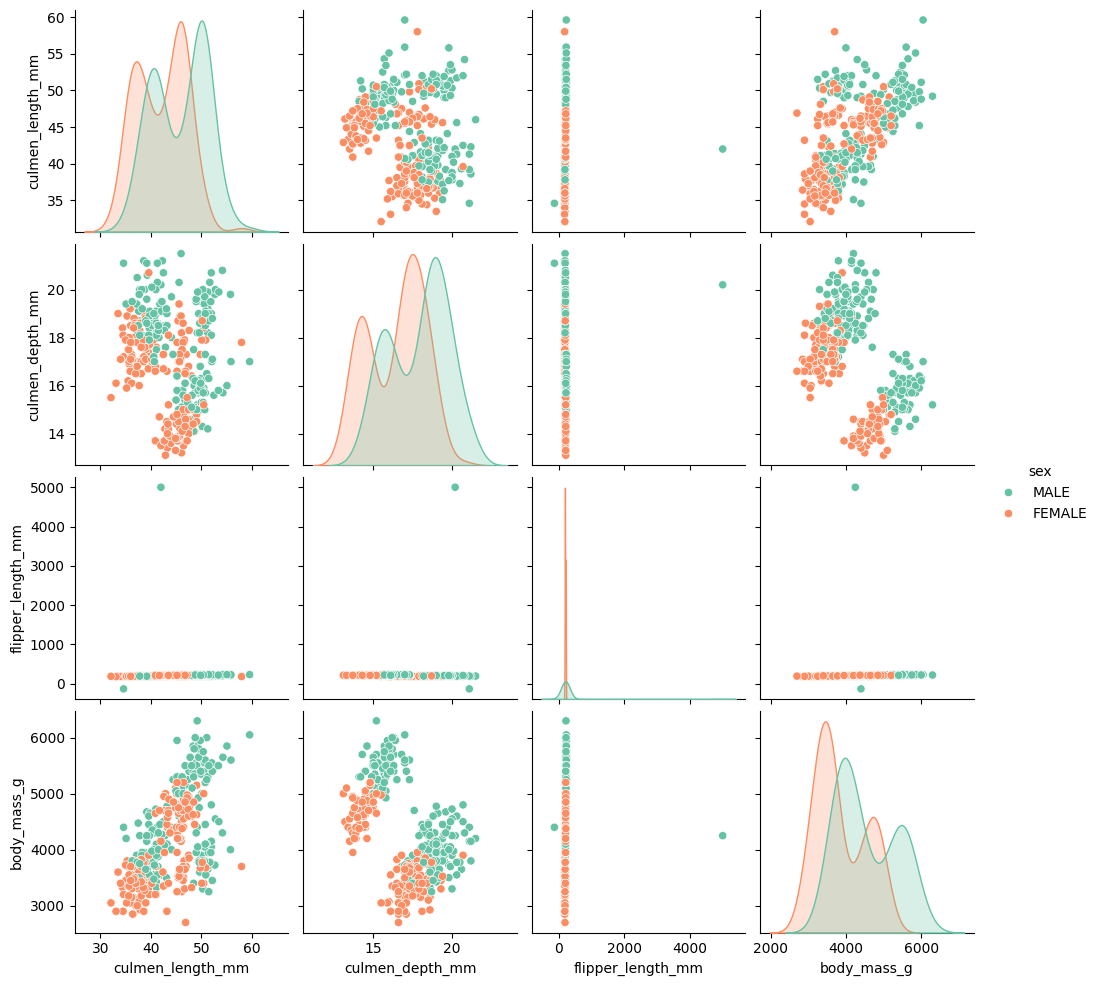

In [25]:

sns.pairplot(df, hue='sex',palette='Set2')

In [ ]:

from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.cluster import KMeans, AgglomerativeClustering


